In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
%matplotlib inline

In [4]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

In [12]:
from catboost import CatBoostClassifier

In [10]:
!pip install catboost

   ---------------------------------------- 0.0/102.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/102.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/102.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/102.4 MB ? eta -:--:--
   ---------------------------------------- 0.5/102.4 MB 1.2 MB/s eta 0:01:26
   ---------------------------------------- 0.5/102.4 MB 1.2 MB/s eta 0:01:26
   ---------------------------------------- 0.8/102.4 MB 799.2 kB/s eta 0:02:08
   ---------------------------------------- 1.0/102.4 MB 839.3 kB/s eta 0:02:01
    --------------------------------------- 1.3/102.4 MB 932.1 kB/s eta 0:01:49
    --------------------------------------- 1.8/102.4 MB 1.1 MB/s eta 0:01:29
    --------------------------------------- 2.1/102.4 MB 1.2 MB/s eta 0:01:25
    --------------------------------------- 2.4/102.4 MB 1.2 MB/s eta 0:01:24
   - -------------------------------------- 2.6/102.4 MB 1.2 MB/s eta 0:01:27
   - ---

In [22]:
base_dir = os.getcwd()
results_dir = os.path.join(base_dir, 'results')
plots_dir = os.path.join(results_dir, 'plots')
reports_dir = os.path.join(results_dir, 'reports')

In [24]:
for d in [results_dir, plots_dir, reports_dir]:
    os.makedirs(d, exist_ok=True)
print('[+] Saving to: ', results_dir)

[+] Saving to:  C:\Users\moham\ML_Practice_learn\ML_Practice\GBM\CatBoost\results


In [30]:
adult = fetch_openml(name='adult', version=2, as_frame=True)

In [32]:
adult.data

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States


In [34]:
adult.target

0        <=50K
1        <=50K
2         >50K
3         >50K
4        <=50K
         ...  
48837    <=50K
48838     >50K
48839    <=50K
48840    <=50K
48841     >50K
Name: class, Length: 48842, dtype: category
Categories (2, object): ['<=50K', '>50K']

In [36]:
adult.feature_names

['age',
 'workclass',
 'fnlwgt',
 'education',
 'education-num',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'native-country']

In [40]:
print(adult.DESCR)

**Author**: Ronny Kohavi and Barry Becker  
**Source**: [UCI](https://archive.ics.uci.edu/ml/datasets/Adult) - 1996  
**Please cite**: Ron Kohavi, "Scaling Up the Accuracy of Naive-Bayes Classifiers: a Decision-Tree Hybrid", Proceedings of the Second International Conference on Knowledge Discovery and Data Mining, 1996  

Prediction task is to determine whether a person makes over 50K a year. Extraction was done by Barry Becker from the 1994 Census database. A set of reasonably clean records was extracted using the following conditions: ((AAGE>16) && (AGI>100) && (AFNLWGT>1)&& (HRSWK>0))

This is the original version from the UCI repository, with training and test sets merged.

### Variable description

Variables are all self-explanatory except __fnlwgt__. This is a proxy for the demographic background of the people: "People with similar demographic characteristics should have similar weights". This similarity-statement is not transferable across the 51 different states.

Description f

In [42]:
X = adult.data
y = adult.target

In [46]:
X.shape

(48842, 14)

In [50]:
y.value_counts()

class
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [52]:
X.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States


In [54]:
X = X.replace("?", np.nan)

In [56]:
for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].str.strip()

In [58]:
data = X.copy()

In [60]:
data["target"] = y

In [62]:
data = data.dropna()

In [64]:
X = data.drop(columns="target")
y = data["target"]

In [66]:
X.shape

(45222, 14)

In [68]:
y.value_counts()

target
<=50K    34014
>50K     11208
Name: count, dtype: int64

In [70]:
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

In [72]:
num_cols = [c for c in X.columns if c not in cat_cols]

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

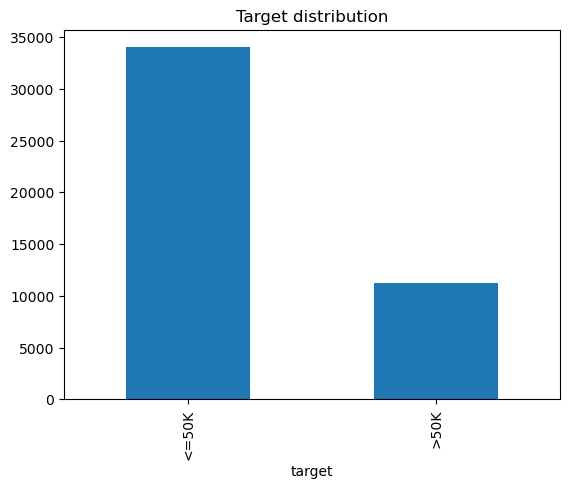

In [82]:
y.value_counts().plot(kind='bar')
plt.title('Target distribution')
plt.show()

In [84]:
col = "age" if "age" in X.columns else num_col[0]

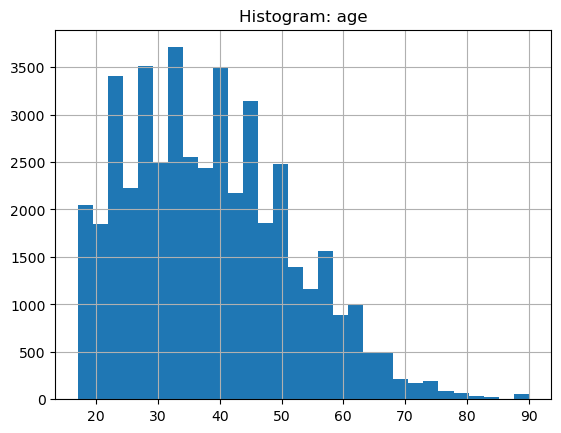

In [86]:
X[col].hist(bins=30)
plt.title(f"Histogram: {col}")
plt.show()

In [100]:
col1 = "education" if "education" in X.columns else cat_cols[0]

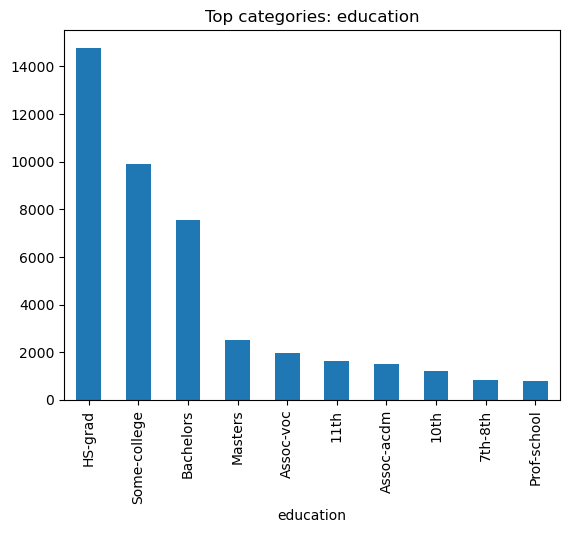

In [104]:
X[col1].value_counts().head(10).plot(kind='bar')
plt.title(f"Top categories: {col1}")
plt.show()

In [110]:
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)    

In [112]:
baseline = Pipeline(steps=[
    ("prep", preprocess),
    ("model", DecisionTreeClassifier(random_state=42, max_depth=8))
])

In [114]:
baseline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country']),
                                                 ('num', 'passthrough',
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week'])])),
                ('model',
                 DecisionTreeClassifier(max_depth=8, random_state=42))])

In [116]:
y_base_pred = baseline.predict(X_test)

In [118]:
baseline_matrix = confusion_matrix(y_test, y_base_pred)

In [122]:
print(baseline_matrix)

[[6406  397]
 [ 966 1276]]


In [124]:
print(classification_report(y_test, y_base_pred))

              precision    recall  f1-score   support

       <=50K       0.87      0.94      0.90      6803
        >50K       0.76      0.57      0.65      2242

    accuracy                           0.85      9045
   macro avg       0.82      0.76      0.78      9045
weighted avg       0.84      0.85      0.84      9045



In [126]:
metrics_base = {
    "accuracy": accuracy_score(y_test, y_base_pred),
    "precision": precision_score(y_test, y_base_pred, pos_label=">50K"),
    "recal": recall_score(y_test, y_base_pred, pos_label=">50K"),
    "f1": f1_score(y_test, y_base_pred, pos_label=">50K"),
}

In [128]:
metrics_base

{'accuracy': 0.8493090105030403,
 'precision': 0.7627017334130305,
 'recal': 0.5691347011596789,
 'f1': 0.6518518518518519}

In [130]:
catboost = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100
)

In [132]:
catboost.fit(
    X_train, y_train, 
    cat_features=cat_cols, 
    eval_set=(X_test, y_test),
    use_best_model=True
)

0:	test: 0.8693706	best: 0.8693706 (0)	total: 249ms	remaining: 2m 4s
100:	test: 0.9232754	best: 0.9232754 (100)	total: 12.1s	remaining: 47.7s
200:	test: 0.9256173	best: 0.9256770 (190)	total: 24.5s	remaining: 36.5s
300:	test: 0.9267053	best: 0.9267794 (280)	total: 36.6s	remaining: 24.2s
400:	test: 0.9269817	best: 0.9269919 (398)	total: 48.4s	remaining: 12s
499:	test: 0.9272836	best: 0.9273172 (498)	total: 1m	remaining: 0us

bestTest = 0.9273171515
bestIteration = 498

Shrink model to first 499 iterations.


In [134]:
y_cb_pred = catboost.predict(X_test)

In [136]:
y_proba_cb = catboost.predict_proba(X_test)[:, 1]

In [138]:
print(confusion_matrix(y_test, y_cb_pred))

[[6351  452]
 [ 732 1510]]


In [156]:
metrics_cb = {
    "accuracy": accuracy_score(y_test, y_cb_pred),
    "precision": precision_score(y_test, y_cb_pred, pos_label=">50K"),
    "recall": recall_score(y_test, y_cb_pred, pos_label=">50K"),
    "f1": f1_score(y_test, y_cb_pred, pos_label=">50K"),
}

In [158]:
metrics_cb

{'accuracy': 0.8690989496959646,
 'precision': 0.7696228338430173,
 'recall': 0.6735057983942908,
 'f1': 0.7183634633682208}

In [150]:
print(classification_report(y_test, y_cb_pred))

              precision    recall  f1-score   support

       <=50K       0.90      0.93      0.91      6803
        >50K       0.77      0.67      0.72      2242

    accuracy                           0.87      9045
   macro avg       0.83      0.80      0.82      9045
weighted avg       0.87      0.87      0.87      9045



In [160]:
compare = pd.DataFrame([metrics_base, metrics_cb], index=["baseline_decision_tree", "catboost"])

In [162]:
compare

,accuracy,precision,recal,f1,recall
baseline_decision_tree,0.849309,0.762702,0.569135,0.651852,NaN
catboost,0.869099,0.769623,NaN,0.718363,0.673506
